In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# %matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


<Axes: xlabel='Weight', ylabel='Height'>

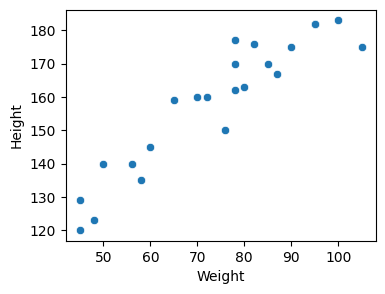

In [10]:
plt.figure(figsize=(4,3))
sns.scatterplot(df,x= 'Weight', y = 'Height')

In [11]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


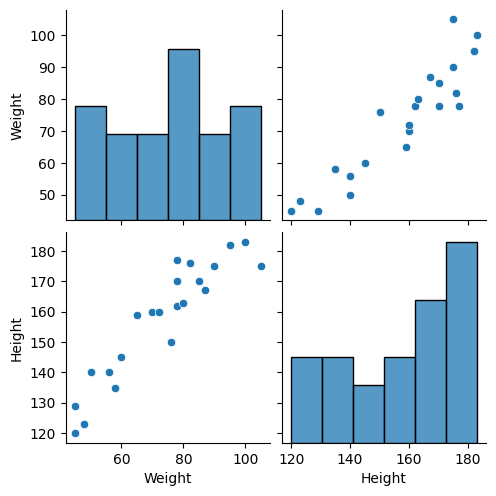

In [12]:
sns.pairplot(df)

In [15]:
## Independent and dependent features
X=df[['Weight']] ### independent features should be data frame or 2 dimesnionalarray
y=df['Height'] ## this variiable can be in series or 1d array


In [13]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [20]:
scal = StandardScaler()

X_scal_T = scal.fit_transform(X_train)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_scal_T, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


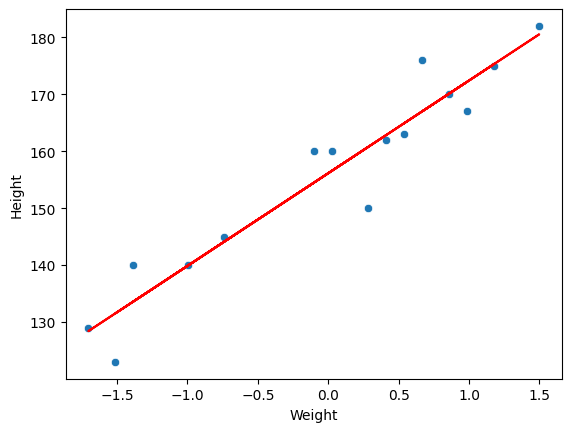

In [34]:
# sns.scatterplot(x = pd.DataFrame(data = {'Weight':X_scal_T, 'Weight': y_train} ))
sns.scatterplot(data = pd.DataFrame(data = {'Weight':X_scal_T.ravel(), 'Height': y_train} ), x= 'Weight', y = 'Height')
plt.plot(X_scal_T,lr.predict(X_scal_T), color = "r" )

## Evaluation

In [35]:
from sklearn import metrics

In [37]:
X_scal_Test = scal.transform(X_test)

In [44]:
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,lr.predict(X_scal_Test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,lr.predict(X_scal_Test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,lr.predict(X_scal_Test))),2)) ## Unit issue

MEAN ABSOLUTE ERROR: 8.33
MEAN SQUARED ERROR: 91.43
ROOT MEAN SQUARED ERROR: 9.56


In [52]:
## R2 And Adjusted Square
print("R-SQUARE:" ,round(metrics.r2_score(y_test,lr.predict(X_scal_Test)),2))

# 1- ((1-R2) *(n-1)/(n-k-1)
adjus_R2 = round((1- ((1-metrics.r2_score(y_test,lr.predict(X_scal_Test))) * (y_test.shape[0]-1) )/((y_test.shape[0]-1) -df.shape[1]-1 )),2)
print("Adjusted R-SQUARE:" ,adjus_R2)

R-SQUARE: 0.81
Adjusted R-SQUARE: 0.66


## OLS

In [54]:
import statsmodels.api as sm

In [55]:
ols = sm.OLS(X_scal_T, y_train).fit()

In [57]:
print(ols.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.011
Model:                            OLS   Adj. R-squared (uncentered):             -0.060
Method:                 Least Squares   F-statistic:                             0.1519
Date:                Tue, 30 Sep 2025   Prob (F-statistic):                       0.703
Time:                        12:46:17   Log-Likelihood:                         -21.203
No. Observations:                  15   AIC:                                      44.41
Df Residuals:                      14   BIC:                                      45.11
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------